In [1]:
# Mass vs Longevity + LQ 
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

os.chdir('/Aging/LQ_TACIT/')
os.getcwd()

'/projects/pfenninggroup/Aging/LQ_TACIT'

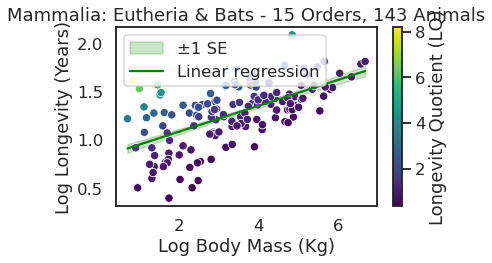

In [122]:
# Manuscript Figure 1A --------------------------------------------------------
#------------------------------------------------------------------------------

# Load data
div = pd.read_csv('/Aging/LQ_TACIT/data/240_predictions_NamesList_DivTime.txt', sep='\t')
div = div.loc[:, ~div.columns.str.contains('^Unnamed: 1')]
div.columns = ['animal', 'Div.Time']

df = pd.read_csv('/Aging/LQ_TACIT/data/teeling_longevity_2-12-21.csv')
#df = df[df['order'] == 'Primates'].sort_values(by='animal')
df = div.merge(df, on='animal', how='left')
df = df.loc[:, df.columns.isin(['animal','l.long','l.mass', 'LQ'])].dropna()

# Columns
animal_col = 'animal'
mass_col = 'l.mass'      # log10 body mass
longevity_col = 'l.long' # log10 longevity
lq_col = 'LQ'            # longevity quotient

# Predictor and response
X = df[[mass_col]].values.reshape(-1,1)
X_flat = X.flatten()
y = df[longevity_col].values

# Fit regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
    
# Standard error
n = len(X_flat)
x_mean = np.mean(X_flat)
residuals = y - y_pred
resid_std = np.std(residuals, ddof=1)
SE = resid_std * np.sqrt(1/n + ((X_flat - x_mean)**2 / np.sum((X_flat - x_mean)**2)))

# Sort for plotting
idx = X_flat.argsort()
X_sorted = X_flat[idx]
y_pred_sorted = y_pred[idx]
SE_sorted = SE[idx]

# Plot scatter with white border
plt.figure(figsize=(6,4))

# SE band (bottom)
plt.fill_between(X_sorted,
                 y_pred_sorted - SE_sorted,
                 y_pred_sorted + SE_sorted,
                 color='green', alpha=0.2, label='±1 SE', zorder=2)

# Scatter (middle)
sc = plt.scatter(df[mass_col], df[longevity_col],
                 c=df[lq_col], cmap='viridis', s=70,
                 edgecolor='white', linewidth=0.8, zorder=3)
cbar = plt.colorbar(sc)
cbar.set_label('Longevity Quotient (LQ)')

# Regression line (top)
plt.plot(X_sorted, y_pred_sorted,
         color='green', label='Linear regression', zorder=4)

# Label only selected species
target_species = [
    'Myotis_brandtii',
    'Myosorex_varius',
    'Mus_musculus',
    'Homo_sapiens',
    'Macaca_mulatta',
    'Pan_troglodytes',
    'Gorilla_gorilla'
]
#subset = df[df[animal_col].isin(target_species)]
#for _, row in subset.iterrows():
#    plt.text(row[mass_col], row[longevity_col], row[animal_col].replace('_',' '),
#             fontsize=10, alpha=0.9, zorder=5)

# Labels and title
plt.xlabel('Log Body Mass (Kg)')
plt.ylabel('Log Longevity (Years)')
plt.title('Mammalia: Eutheria & Bats - 15 Orders, 143 Animals')
plt.legend(loc='upper left')
plt.tight_layout()
#plt.show()

#plt.savefig('plots/Mass_vs_Longevity_LQ_unlabeled.pdf', bbox_inches='tight', dpi=300)

In [123]:
# Divergence Time from Humans vs. Model Predictions (all cell types)

# Directory with cell-type folders
DIR = '/machineLearningForComputationalBiology/Cortex_Cell-TACIT/data/tidy_data/240_predictions_matrix_species/Human/'

# List all cell-type folders
#cell_types = [f for f in os.listdir(DIR) if os.path.isdir(os.path.join(DIR, f))]
cell_types= ['L2.3.IT', 'L3.4.IT', 'L4.5.IT', 'L5.6.IT.Car3', 'L5.6.NP', 'L5.ET', 'L5.IT', 'L6.CT', 'L6.IT','L6b', 
'LAMP5', 'PAX6', 'PVALB', 'SST', 'VIP',
'Astro', 'Endo', 'Microglia', 'Oligo', 'Opc']

# Dictionary to hold mean predictions per cell type
mean_dict = {}

for cell in cell_types:
    print(cell)
    # Paths
    matrix_file = os.path.join(DIR, cell, '240_predictions_Matrix.tsv')
    names_file = os.path.join(DIR, cell, '240_predictions_NamesList.txt')
    
    # Read matrix and names
    matrix = (
    pd.read_csv(matrix_file, sep='\t', header=None, index_col=0)
      .replace(-1, 0))
    names = pd.read_csv(names_file, sep='\t', header=None, index_col=0).index.tolist()
    
    # Assign column names
    matrix.columns = names
    
    # Compute mean predictions per species (mean across columns)
    mean_pred = matrix.mean(axis=0)
    print(mean_pred)
    
    # Store in dictionary
    mean_dict[cell] = mean_pred

# Combine all cell types into one DataFrame
mean_df = pd.DataFrame(mean_dict)
mean_df['animal']=mean_df.index

print(mean_df.shape)

# --- Merge with divergence time table ---
div = pd.read_csv('/Aging/LQ_TACIT/data/240_predictions_NamesList_DivTime.txt', sep='\t')
div = div.loc[:, ~div.columns.str.contains('^Unnamed: 1')]
div.columns = ['animal', 'Div.Time']

# Make sure species names match
merged = div.merge(mean_df, on='animal', how='left').dropna(axis=1)
#merged = merged.drop(columns=['animal'])

L2.3.IT
Acinonyx_jubatus          0.362567
Acomys_cahirinus          0.377591
Ailuropoda_melanoleuca    0.456212
Ailurus_fulgens           0.445402
Allactaga_bullata         0.353119
                            ...   
Vulpes_lagopus            0.447146
Xerus_inauris             0.433529
Zalophus_californianus    0.479789
Zapus_hudsonius           0.335455
Ziphius_cavirostris       0.418840
Length: 241, dtype: float64
L3.4.IT
Acinonyx_jubatus          0.324558
Acomys_cahirinus          0.326441
Ailuropoda_melanoleuca    0.385095
Ailurus_fulgens           0.381359
Allactaga_bullata         0.307206
                            ...   
Vulpes_lagopus            0.379792
Xerus_inauris             0.386544
Zalophus_californianus    0.406369
Zapus_hudsonius           0.293717
Ziphius_cavirostris       0.355897
Length: 241, dtype: float64
L4.5.IT
Acinonyx_jubatus          0.367721
Acomys_cahirinus          0.397283
Ailuropoda_melanoleuca    0.472507
Ailurus_fulgens           0.462480
Allactaga_

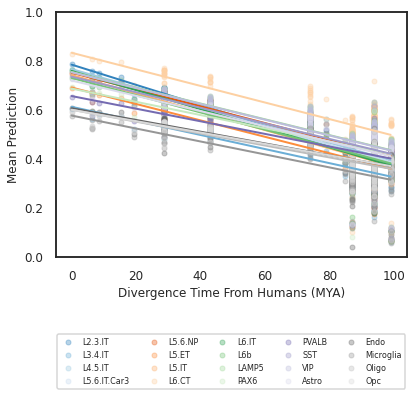

In [138]:
# Manuscript Supp Figure 1B ---------------------------------------------------
#------------------------------------------------------------------------------

cell_types = [
    'L2.3.IT', 'L3.4.IT', 'L4.5.IT', 'L5.6.IT.Car3', 'L5.6.NP',
    'L5.ET', 'L5.IT', 'L6.CT', 'L6.IT', 'L6b',
    'LAMP5', 'PAX6', 'PVALB', 'SST', 'VIP',
    'Astro', 'Endo', 'Microglia', 'Oligo', 'Opc'
]

# Convert to long format
plot_df = merged.melt(
    id_vars='Div.Time',
    value_vars=[c for c in cell_types if c in merged.columns],
    var_name='CellType',
    value_name='Prediction'
).dropna()

# Color palette
palette = sns.color_palette('tab20c', n_colors=len(cell_types))
color_dict = dict(zip(cell_types, palette))

plt.figure(figsize=(6,6))

# Global font size controls
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# Scatter + regression per cell type
for cell in cell_types:

    sub = plot_df[plot_df['CellType'] == cell]

    if sub.empty:
        continue

    sns.regplot(
        data=sub,
        x='Div.Time',
        y='Prediction',
        scatter=True,
        ci=None,
        scatter_kws={
            's': 25,
            'alpha': 0.35
        },
        line_kws={
            'linewidth': 2
        },
        color=color_dict[cell],
        label=cell
    )

plt.xlabel('Divergence Time From Humans (MYA)')
plt.ylabel('Mean Prediction')
#plt.title('Mean Prediction per Cell Type vs Divergence Time')

# Set y-axis range
plt.ylim(0, 1)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.3),
    ncol=5,
    fontsize=8
)

plt.tight_layout()
#plt.show()
#plt.savefig('plots/DivTime_Humans_vs_Model_Predictions.pdf', bbox_inches='tight', dpi=300)

In [2]:
# LQ / Longevity -- Pooled associated OCR with LQ
DIR1='/Aging/LQ_TACIT/phylolm/'
lq_pos=pd.read_csv(DIR1+'phylolm_r0_s1_bh_corrected_pos.bed', sep='\t', header=None, names=['chr', 'start', 'end','peak'])
lq_neg=pd.read_csv(DIR1+'phylolm_r0_s1_bh_corrected_neg.bed', sep='\t', header=None, names=['chr', 'start', 'end','peak'])

# Background (aging_pos + lq_neg)
bgd=pd.read_csv('/Aging/LQ_TACIT/data/tables/bgd_all_nuclei_longevity_neg_aging_pos.bed',sep ='\t', header = None, names=['chr', 'start', 'end','peak'])

# Overlapping peaks Aging + Longevity
all_nuclei_neg_aging_pos=pd.read_csv('/Aging/LQ_TACIT/data/tables/Overlap_all_nuclei_neg_aging_pos.bed',sep ='\t', header = None, names=['chr', 'start', 'end','peak'])
PVALB_neg_aging_pos=pd.read_csv('/Aging/LQ_TACIT/data/tables/Overlap_PVALB_neg_aging_pos.bed',sep ='\t',header = None, names=['chr', 'start', 'end','peak'])
SST_neg_aging_pos=pd.read_csv('/Aging/LQ_TACIT/data/tables/Overlap_SST_neg_aging_pos.bed',sep ='\t',header = None, names=['chr', 'start', 'end','peak'])
L5_ET_neg_aging_pos=pd.read_csv('/Aging/LQ_TACIT/data/tables/Overlap_L5.ET_neg_aging_pos.bed',sep ='\t',header = None, names=['chr', 'start', 'end','peak'])

In [104]:
# Per cell type

# Divergence Time from Humans vs. Model Predictions (all cell types)

# Directory with cell-type folders
DIR = '/machineLearningForComputationalBiology/Cortex_Cell-TACIT/data/tidy_data/240_predictions_matrix_species/Human/'

# List all cell-type folders
cell_types = [f for f in os.listdir(DIR) if os.path.isdir(os.path.join(DIR, f))]
cell_types = cell_types= ['SST']

# Dictionary to hold mean predictions per cell type
mean_dict = {}

for cell in cell_types:
    # Paths
    matrix_file = os.path.join(DIR, cell, '240_predictions_Matrix.tsv')
    names_file = os.path.join(DIR, cell, '240_predictions_NamesList.txt')
    
    # Read matrix and names
    matrix = (
    pd.read_csv(matrix_file, sep='\t', header=None, index_col=0)
      .replace(-1, 0))
    names = pd.read_csv(names_file, sep='\t', header=None, index_col=0).index.tolist()
    
    # Assign column names
    matrix.columns = names
    
    overlapping = np.intersect1d(matrix.index, SST_neg_aging_pos.loc[:, 3])

    # keep only non-overlapping rows
    matrix_filtered = matrix[~matrix.index.isin(overlapping)]
    # keep only overlapping rows
    matrix_vul = matrix[matrix.index.isin(overlapping)]

    # Compute mean predictions per species (mean across columns)
    mean_pred_filtered = matrix_filtered.mean(axis=0)
    mean_pred_vul = matrix_vul.mean(axis=0)
    

# Compute mean predictions per species
mean_pred_filtered = matrix_filtered.mean(axis=0)
mean_pred_vul = matrix_vul.mean(axis=0)

# convert to dataframe with correct structure
mean_pred_filtered = mean_pred_filtered.to_frame(name='mean_pred')
mean_pred_vul = mean_pred_vul.to_frame(name='mean_pred')

# add metadata
mean_pred_filtered['animal'] = mean_pred_filtered.index
mean_pred_filtered['group'] = 'PVALB_non_vulnerable'

mean_pred_vul['animal'] = mean_pred_vul.index
mean_pred_vul['group'] = 'PVALB_vulnerable'


mean_df = pd.concat([mean_pred_filtered, mean_pred_vul], axis=0)

# --- Merge with divergence time table ---
div = pd.read_csv('/Aging/LQ_TACIT/data/240_predictions_NamesList_DivTime.txt', sep='\t')
div = div.loc[:, ~div.columns.str.contains('^Unnamed: 1')]
div.columns = ['animal', 'Div_Time']

df = pd.read_csv('/Aging/LQ_TACIT/data/teeling_longevity_2-12-21.csv')
#df = df[df['order'] == 'Primates'].sort_values(by='animal')
df = div.merge(df, on='animal', how='left')
df = df.loc[:, df.columns.isin(['animal','Div_Time','l.long','l.mass', 'LQ'])].dropna()
df.columns = ['animal','Div_Time','l_long','l_mass', 'LQ']

merged = mean_df.merge(df, on='animal', how='left')

PVALB
SST
L5.ET


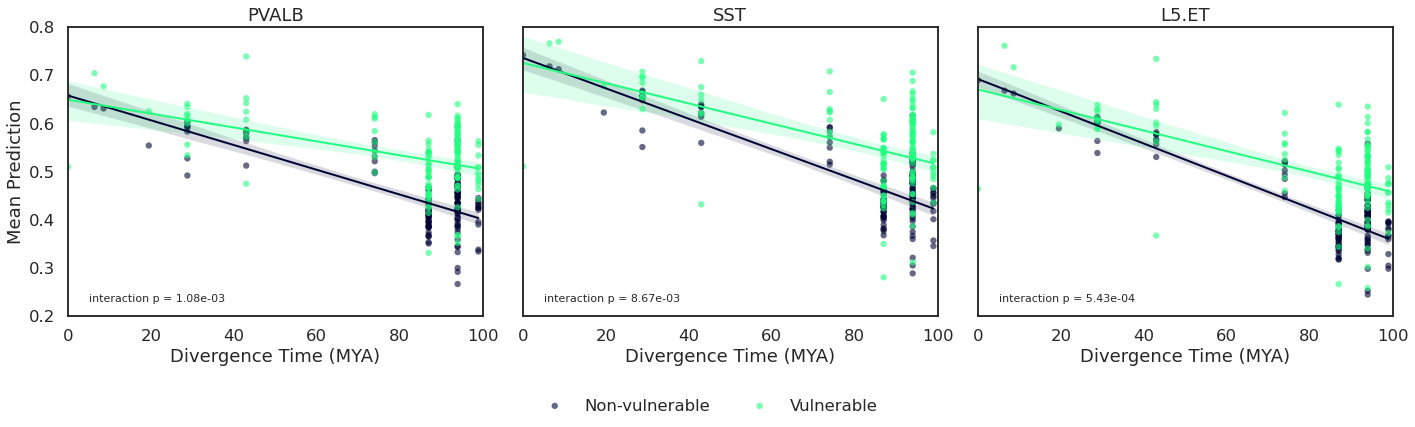

In [32]:
# Manuscript Figure 9E --------------------------------------------------------
#------------------------------------------------------------------------------


sns.set(style="white", context="talk")

# --------------------------------------------------
# Cell types + vulnerable peak sets
# --------------------------------------------------
celltype_info = {
    "PVALB": PVALB_neg_aging_pos,
    "SST": SST_neg_aging_pos,
    "L5.ET": L5_ET_neg_aging_pos
}

# --------------------------------------------------
# Divergence / longevity metadata
# --------------------------------------------------
div = pd.read_csv('/Aging/LQ_TACIT/data/240_predictions_NamesList_DivTime.txt', sep='\t')
div = div.loc[:, ~div.columns.str.contains('^Unnamed: 1')]
div.columns = ['animal', 'Div_Time']

df_meta = pd.read_csv('/Aging/LQ_TACIT/data/teeling_longevity_2-12-21.csv')

df_meta = div.merge(df_meta, on='animal', how='left')

df_meta = (
    df_meta.loc[:, ['animal', 'Div_Time', 'LQ']]
    .dropna()
)

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

#palette = sns.color_palette("tab10", 2)
palette = ('#000435', '#21fe80')

DIR = '/machineLearningForComputationalBiology/Cortex_Cell-TACIT/data/tidy_data/240_predictions_matrix_species/Human/'

# --------------------------------------------------
# Loop through cell types
# --------------------------------------------------
for ax, (cell, vuln_df) in zip(axes, celltype_info.items()):
    print(cell)

    # --------------------------
    # Load prediction matrix
    # --------------------------
    matrix_file = os.path.join(DIR, cell, '240_predictions_Matrix.tsv')
    names_file  = os.path.join(DIR, cell, '240_predictions_NamesList.txt')

    matrix = (
        pd.read_csv(matrix_file, sep='\t', header=None, index_col=0)
        .replace(-1, 0)
    )

    names = pd.read_csv(
        names_file,
        sep='\t',
        header=None,
        index_col=0
    ).index.tolist()

    matrix.columns = names

    # --------------------------
    # Split vulnerable vs non
    # --------------------------
    overlapping = np.intersect1d(matrix.index, vuln_df.loc[:, 'peak'])

    matrix_non = matrix[~matrix.index.isin(overlapping)]
    matrix_vul = matrix[matrix.index.isin(overlapping)]

    # --------------------------
    # Mean predictions
    # --------------------------
    mean_non = (
        matrix_non.mean(axis=0)
        .to_frame(name='mean_pred')
    )

    mean_vul = (
        matrix_vul.mean(axis=0)
        .to_frame(name='mean_pred')
    )

    mean_non['animal'] = mean_non.index
    mean_non['group'] = 'Non-vulnerable'

    mean_vul['animal'] = mean_vul.index
    mean_vul['group'] = 'Vulnerable'

    mean_df = pd.concat([mean_non, mean_vul])

    merged = mean_df.merge(df_meta, on='animal', how='left')

    # --------------------------
    # Plot
    # --------------------------
    groups = merged["group"].unique()

    for i, g in enumerate(groups):

        df_g = merged[merged["group"] == g]

        sns.regplot(
            data=df_g,
            x="Div_Time",
            y="mean_pred",
            scatter=True,
            ci=95,
            ax=ax,
            scatter_kws={
                "alpha": 0.6,
                "s": 40,
                "edgecolor": "none"
            },
            line_kws={
                "linewidth": 2
            },
            color=palette[i],
            label=g
        )
        # manually set scales
        ax.set_xlim(0, 100)      # x-axis range
        ax.set_ylim(0.2, 0.8)      # y-axis range

    # --------------------------
    # Interaction model
    # --------------------------
    model = smf.ols(
        "mean_pred ~ Div_Time * group",
        data=merged
    ).fit()

    interaction_term = "Div_Time:group[T.Vulnerable]"
    pval = model.pvalues.get(interaction_term, np.nan)

    # --------------------------
    # Styling
    # --------------------------
    ax.set_title(cell)

    ax.set_xlabel("Divergence Time (MYA)")

    if ax == axes[0]:
        ax.set_ylabel("Mean Prediction")

    else:
        ax.set_ylabel("")

    ax.grid(False)

    ax.text(
        0.05,
        0.05,
        f"interaction p = {pval:.2e}",
        transform=ax.transAxes,
        fontsize=11
    )

# --------------------------------------------------
# Legend
# --------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('plots/DivTime_Humans_vs_Model_Predictions_Vulnerability.pdf', bbox_inches='tight', dpi=300)